# INVESTIGATION 1: UNDERSTAND THE DATASET

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Set visualization style

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
# load dataset
df = pd.read_csv('StayEase_Cleaned_Dataset.csv')

## 1.1 Dataset Description

In [38]:
print(f"\nDataset Name: StayEase Booking Analytics Dataset")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Dataset Name: StayEase Booking Analytics Dataset
Total Records: 102,658
Total Features: 37
Memory Usage: 94.80 MB


## 1.2 Display Sample Data

In [12]:
display(df.head(10))

,hotel_type,booking_status,advance_booking_days,arrival_year,arrival_month,arrival_week,arrival_day,weekend_nights,weekday_nights,num_adults,num_children,num_infants,meal_plan,guest_country,booking_segment,booking_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room,assigned_room,modifications,deposit_type,travel_agent_id,corporate_id,waiting_days,customer_category,avg_daily_rate,parking_spaces,special_requests,reservation_status,reservation_date,total_stay_nights,booking_season,family_booking,total_guests,is_long_stay
0,Luxury Resort,1,2,2016,June,24,5,1,0,2,0.0,0,SB,Unknown,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,Not Applicable,0,Regular,109.00,0,1,Cancelled,04-06-2016,1,Summer,0,2.0,0
1,Urban Hotel,1,82,2016,September,38,15,0,3,2,0.0,0,SB,GBR,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,Not Applicable,0,Regular,149.40,0,1,Cancelled,12-09-2016,3,Autumn,0,2.0,0
2,Luxury Resort,0,62,2015,August,34,20,2,8,2,0.0,0,SB,ESP,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,243.0,Not Applicable,0,Regular,104.00,0,0,Checked-Out,30-08-2015,10,Summer,0,2.0,1
3,Urban Hotel,0,133,2016,May,21,17,0,3,2,0.0,0,SB,NLD,Online TA,TA/TO,0,0,0,A,B,1,No Deposit,9.0,Not Applicable,0,Regular-Party,105.30,0,0,Checked-Out,20-05-2016,3,Spring,0,2.0,0
4,Luxury Resort,1,87,2016,August,33,12,1,2,2,1.0,0,SB,BRA,Direct,Direct,0,0,0,A,A,0,No Deposit,250.0,Not Applicable,0,Regular,204.00,0,0,Cancelled,02-06-2016,3,Summer,1,3.0,0
5,Urban Hotel,0,15,2016,September,39,20,0,1,2,0.0,0,SB,PRT,Online TA,TA/TO,0,0,0,A,A,1,No Deposit,9.0,Not Applicable,0,Regular,139.00,0,1,Checked-Out,21-09-2016,1,Autumn,0,2.0,0
6,Urban Hotel,0,51,2016,July,29,15,0,1,2,0.0,0,SC,SWE,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,Not Applicable,0,Regular,94.50,0,0,Checked-Out,16-07-2016,1,Summer,0,2.0,0
7,Urban Hotel,1,327,2015,September,37,9,0,2,2,0.0,0,SB,PRT,Group Bookings,TA/TO,0,1,0,A,A,0,Non Refund,1.0,Not Applicable,0,Regular-Party,62.00,0,0,Cancelled,02-07-2015,2,Autumn,0,2.0,0
8,Urban Hotel,0,138,2017,May,21,27,2,3,1,0.0,0,SB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,7.0,Not Applicable,0,Regular,90.09,0,1,Checked-Out,01-06-2017,5,Spring,0,1.0,0
9,Urban Hotel,1,228,2017,May,21,24,0,4,3,0.0,0,SB,GBR,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.0,Not Applicable,0,Regular,157.50,0,1,Cancelled,22-10-2016,4,Spring,0,3.0,0


## 1.3 Attribute Classification

In [13]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
datetime_features = [col for col in df.columns if 'date' in col.lower()]

print(f"\nNumerical Features ({len(numerical_features)}):")
for i, feat in enumerate(numerical_features, 1):
    print(f"  {i}. {feat}")

print(f"\nCategorical Features ({len(categorical_features)}):")
for i, feat in enumerate(categorical_features, 1):
    print(f"  {i}. {feat}")

print(f"\nDate/Time Features ({len(datetime_features)}):")
for i, feat in enumerate(datetime_features, 1):
    print(f"  {i}. {feat}")


Numerical Features (23):
  1. booking_status
  2. advance_booking_days
  3. arrival_year
  4. arrival_week
  5. arrival_day
  6. weekend_nights
  7. weekday_nights
  8. num_adults
  9. num_children
  10. num_infants
  11. is_repeated_guest
  12. previous_cancellations
  13. previous_bookings_not_canceled
  14. modifications
  15. travel_agent_id
  16. waiting_days
  17. avg_daily_rate
  18. parking_spaces
  19. special_requests
  20. total_stay_nights
  21. family_booking
  22. total_guests
  23. is_long_stay

Categorical Features (14):
  1. hotel_type
  2. arrival_month
  3. meal_plan
  4. guest_country
  5. booking_segment
  6. booking_channel
  7. reserved_room
  8. assigned_room
  9. deposit_type
  10. corporate_id
  11. customer_category
  12. reservation_status
  13. reservation_date
  14. booking_season

Date/Time Features (1):
  1. reservation_date


## 1.4 Detailed Attribute Classification Table

In [14]:
attribute_table = pd.DataFrame({
    'Feature': df.columns,
    'Data Type': df.dtypes.values,
    'Category': ['Numerical' if df[col].dtype in ['int64', 'float64'] 
                 else 'Categorical' if df[col].dtype == 'object' 
                 else 'Other' for col in df.columns],
    'Unique Values': [df[col].nunique() for col in df.columns],
    'Null Values': [df[col].isnull().sum() for col in df.columns],
    'Null %': [(df[col].isnull().sum()/len(df))*100 for col in df.columns],
    'Sample Values': [str(df[col].iloc[0]) if len(df[col].unique()) > 5 
                     else ', '.join([str(x) for x in df[col].unique()]) 
                     for col in df.columns]
})

# Reorder columns for better readability
attribute_table = attribute_table[['Feature', 'Category', 'Data Type', 
                                   'Unique Values', 'Null Values', 'Null %', 
                                   'Sample Values']]
display(attribute_table)

,Feature,Category,Data Type,Unique Values,Null Values,Null %,Sample Values
0,hotel_type,Other,str,2,0,0.000000,"Luxury Resort, Urban Hotel"
1,booking_status,Numerical,int64,2,0,0.000000,"1, 0"
2,advance_booking_days,Numerical,int64,479,0,0.000000,2
3,arrival_year,Numerical,int64,3,0,0.000000,"2016, 2015, 2017"
4,arrival_month,Other,str,12,0,0.000000,June
5,arrival_week,Numerical,int64,53,0,0.000000,24
6,arrival_day,Numerical,int64,31,0,0.000000,5
7,weekend_nights,Numerical,int64,17,0,0.000000,1
8,weekday_nights,Numerical,int64,35,0,0.000000,0
9,num_adults,Numerical,int64,4,0,0.000000,"2, 1, 3, 0"


# INVESTIGATION 2: EVALUATE DATA READINESS

## 2.1 Missing Values Analysis

missing_data = pd.DataFrame({
    'Feature': df.columns,
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values('Missing %', ascending=False)

if len(missing_data) > 0:
    print(f"Found {len(missing_data)} features with missing values:")
    display(missing_data)
    
    print("\nDetailed Analysis:")
    for idx, row in missing_data.iterrows():
        print(f"\nFeature: {row['Feature']}")
        print(f"  Missing Values: {int(row['Missing Values']):,}")
        print(f"  Missing Percentage: {row['Missing %']:.2f}%")
        print(f"  Issue Importance: This missing data could affect {'business decisions' if row['Missing %'] > 10 else 'analysis reliability'}")
        print(f"  Recommended Action: {'Remove feature' if row['Missing %'] > 40 else 'Impute values' if row['Missing %'] > 5 else 'Investigate further'}")
else:
    print("✓ No missing values found in the dataset")


## 2.2 Duplicate Records Analysis

In [16]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate Rows: {duplicate_count:,}")
print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

if duplicate_count > 0:
    print("\nIssue: Duplicate records present in the dataset")
    print("  Impact: May cause data distortion and over-representation of certain bookings")
    print("  Recommended Action: Remove duplicates to ensure data integrity")
else:
    print("✓ No duplicate records found")

Duplicate Rows: 13,260
Duplicate Percentage: 12.92%

Issue: Duplicate records present in the dataset
  Impact: May cause data distortion and over-representation of certain bookings
  Recommended Action: Remove duplicates to ensure data integrity


## 2.3 Data Type Validation

In [17]:
print("Checking for data type inconsistencies:\n")

for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].unique()
        print(f"Feature: {col}")
        print(f"  Current Type: {df[col].dtype}")
        print(f"  Unique Values: {len(unique_vals)}")
        if len(unique_vals) <= 10:
            print(f"  Values: {', '.join([str(x) for x in unique_vals])}")
        else:
            print(f"  Sample Values: {', '.join([str(x) for x in unique_vals[:5]])} ...")
        
        # Check if object column should be categorical
        if len(unique_vals) < len(df) * 0.5:
            print(f"  Recommendation: Convert to categorical type")
        print()

Checking for data type inconsistencies:



## 2.4 Outlier Detection

In [20]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
outlier_summary = []

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count = len(outliers)
    outliers_pct = (outliers_count / len(df)) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Outliers': outliers_count,
        'Percentage': f"{outliers_pct:.2f}%",
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Mean': df[col].mean(),
        'Median': df[col].median()
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df[outlier_df['Outliers'] > 0].sort_values('Outliers', ascending=False)

if len(outlier_df) > 0:
    print("Features with outliers:")
    display(outlier_df)
    
    print("\nIssue Significance:")
    for idx, row in outlier_df.iterrows():
        if float(row['Percentage'].replace('%', '')) > 10:
            print(f"  {row['Feature']}: {row['Outliers']} outliers ({row['Percentage']}) - Significant impact")
        elif float(row['Percentage'].replace('%', '')) > 5:
            print(f"  {row['Feature']}: {row['Outliers']} outliers ({row['Percentage']}) - Moderate impact")
        else:
            print(f"  {row['Feature']}: {row['Outliers']} outliers ({row['Percentage']}) - Minor impact")
else:
    print("✓ No outliers detected in numerical features")


Features with outliers:


,Feature,Outliers,Percentage,Lower Bound,Upper Bound,Min,Max,Mean,Median
21,total_guests,33993,33.11%,2.00,2.00,0.00,4.0,1.990006,2.0
7,num_adults,26168,25.49%,2.00,2.00,0.00,3.0,1.865067,2.0
13,modifications,17113,16.67%,0.00,0.00,0.00,21.0,0.246011,0.0
22,is_long_stay,13157,12.82%,0.00,0.00,0.00,1.0,0.128163,0.0
20,family_booking,9095,8.86%,0.00,0.00,0.00,1.0,0.088595,0.0
8,num_children,8353,8.14%,0.00,0.00,0.00,10.0,0.116513,0.0
17,parking_spaces,7372,7.18%,0.00,0.00,0.00,8.0,0.072279,0.0
19,total_stay_nights,5045,4.91%,-1.00,7.00,0.00,69.0,3.514933,3.0
16,avg_daily_rate,3836,3.74%,-6.05,209.55,0.26,256.5,105.171962,98.0
11,previous_cancellations,3713,3.62%,0.00,0.00,0.00,26.0,0.056732,0.0



Issue Significance:
  total_guests: 33993 outliers (33.11%) - Significant impact
  num_adults: 26168 outliers (25.49%) - Significant impact
  modifications: 17113 outliers (16.67%) - Significant impact
  is_long_stay: 13157 outliers (12.82%) - Significant impact
  family_booking: 9095 outliers (8.86%) - Moderate impact
  num_children: 8353 outliers (8.14%) - Moderate impact
  parking_spaces: 7372 outliers (7.18%) - Moderate impact
  total_stay_nights: 5045 outliers (4.91%) - Minor impact
  avg_daily_rate: 3836 outliers (3.74%) - Minor impact
  previous_cancellations: 3713 outliers (3.62%) - Minor impact
  is_repeated_guest: 3650 outliers (3.56%) - Minor impact
  previous_bookings_not_canceled: 3626 outliers (3.53%) - Minor impact
  weekday_nights: 3217 outliers (3.13%) - Minor impact
  advance_booking_days: 2836 outliers (2.76%) - Minor impact
  special_requests: 2817 outliers (2.74%) - Minor impact
  waiting_days: 2051 outliers (2.00%) - Minor impact
  num_infants: 913 outliers (0.89

# investigation 3

In [23]:
df_clean = df.copy()
preprocessing_log = []
missing_columns = [col for col in df_clean.columns if df_clean[col].isnull().sum() > 0]

for col in missing_columns:
    missing_count = df_clean[col].isnull().sum()
    missing_pct = (missing_count / len(df_clean)) * 100
    
    if df_clean[col].dtype in ['int64', 'float64']:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        preprocessing_log.append({
            'Issue': f'Missing values in {col}',
            'Evidence': f'{missing_count:,} missing ({missing_pct:.2f}%)',
            'Action Taken': f'Imputed with median ({median_val:.2f})',
            'Justification': 'Median is robust to outliers',
            'Impact': f'Preserved {missing_count:,} records'
        })
    elif df_clean[col].dtype == 'object':
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        preprocessing_log.append({
            'Issue': f'Missing values in {col}',
            'Evidence': f'{missing_count:,} missing ({missing_pct:.2f}%)',
            'Action Taken': f'Imputed with mode ({mode_val})',
            'Justification': 'Mode represents most common category',
            'Impact': f'Preserved {missing_count:,} records'
        })

In [24]:
duplicate_count = df_clean.duplicated().sum()

if duplicate_count > 0:
    df_clean.drop_duplicates(inplace=True)
    preprocessing_log.append({
        'Issue': 'Duplicate rows',
        'Evidence': f'{duplicate_count:,} duplicates ({duplicate_count/len(df)*100:.2f}%)',
        'Action Taken': 'Removed duplicate rows',
        'Justification': 'Duplicates cause data distortion',
        'Impact': f'Reduced dataset by {duplicate_count:,} rows'
    })

In [25]:
zero_adults = (df_clean['num_adults'] == 0).sum()

if zero_adults > 0:
    df_clean = df_clean[df_clean['num_adults'] > 0]
    preprocessing_log.append({
        'Issue': 'Zero adults in booking',
        'Evidence': f'{zero_adults:,} bookings with 0 adults',
        'Action Taken': 'Removed invalid bookings',
        'Justification': 'Booking must have at least one adult',
        'Impact': f'Removed {zero_adults:,} invalid bookings'
    })

In [26]:
categorical_columns = ['hotel_type', 'meal_plan', 'guest_country', 'booking_segment',
                       'booking_channel', 'deposit_type', 'reserved_room', 'assigned_room',
                       'reservation_status', 'booking_season', 'customer_category']

for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

boolean_columns = ['is_repeated_guest', 'family_booking', 'is_long_stay']
for col in boolean_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('bool')

if 'booking_status' in df_clean.columns:
    df_clean['booking_status'] = df_clean['booking_status'].astype('bool')

preprocessing_log.append({
    'Issue': 'Incorrect data types',
    'Evidence': 'Categorical and boolean columns stored as objects/integers',
    'Action Taken': 'Converted to appropriate data types',
    'Justification': 'Correct data types enable proper analysis',
    'Impact': 'Improved data structure and efficiency'
})

In [27]:
if 'avg_daily_rate' in df_clean.columns and 'total_stay_nights' in df_clean.columns:
    df_clean['total_revenue'] = df_clean['avg_daily_rate'] * df_clean['total_stay_nights']

if 'num_adults' in df_clean.columns and 'num_children' in df_clean.columns:
    df_clean['occupancy_rate'] = (df_clean['num_adults'] + df_clean['num_children']) / 4
    df_clean['occupancy_rate'] = df_clean['occupancy_rate'].clip(0, 1)

if 'weekend_nights' in df_clean.columns and 'total_stay_nights' in df_clean.columns:
    df_clean['weekend_ratio'] = df_clean['weekend_nights'] / (df_clean['total_stay_nights'] + 0.001)

if 'num_children' in df_clean.columns and 'family_booking' not in df_clean.columns:
    df_clean['family_booking'] = df_clean['num_children'] > 0

if all(col in df_clean.columns for col in ['num_adults', 'num_children', 'num_infants']):
    df_clean['total_guests'] = df_clean['num_adults'] + df_clean['num_children'] + df_clean['num_infants']

if 'booking_status' in df_clean.columns and 'advance_booking_days' in df_clean.columns:
    df_clean['cancellation_risk'] = pd.cut(
        df_clean['advance_booking_days'],
        bins=[0, 7, 30, 90, 365],
        labels=['Very Low', 'Low', 'Medium', 'High']
    )

preprocessing_log.append({
    'Issue': 'Limited analytical features',
    'Evidence': 'Original dataset lacked derived metrics',
    'Action Taken': 'Created new features: total_revenue, occupancy_rate, weekend_ratio, total_guests, cancellation_risk',
    'Justification': 'New features provide deeper business insights',
    'Impact': 'Enhanced analytical capability with 5 new features'
})

In [28]:
preprocessing_df = pd.DataFrame(preprocessing_log)
display(preprocessing_df)

print(f"Initial shape: {df.shape}")
print(f"Final shape: {df_clean.shape}")
print(f"Missing values after processing: {df_clean.isnull().sum().sum()}")

,Issue,Evidence,Action Taken,Justification,Impact
0,Missing values in travel_agent_id,"16,751 missing (16.32%)",Imputed with median (13.00),Median is robust to outliers,"Preserved 16,751 records"
1,Duplicate rows,"13,260 duplicates (12.92%)",Removed duplicate rows,Duplicates cause data distortion,"Reduced dataset by 13,260 rows"
2,Zero adults in booking,173 bookings with 0 adults,Removed invalid bookings,Booking must have at least one adult,Removed 173 invalid bookings
3,Incorrect data types,Categorical and boolean columns stored as obje...,Converted to appropriate data types,Correct data types enable proper analysis,Improved data structure and efficiency
4,Limited analytical features,Original dataset lacked derived metrics,"Created new features: total_revenue, occupancy...",New features provide deeper business insights,Enhanced analytical capability with 5 new feat...


Initial shape: (102658, 37)
Final shape: (89225, 41)
Missing values after processing: 21751


In [29]:
df_clean.to_csv('StayEase_Analysis_Ready_Dataset.csv', index=False)

# investigation 4

In [30]:
status_counts = df['booking_status'].value_counts()
status_pct = df['booking_status'].value_counts(normalize=True) * 100
cancellation_rate = status_counts.get(1, 0) / len(df) * 100

print(f"Checked-Out: {status_counts.get(0, 0):,} ({status_pct.get(0, 0):.2f}%)")
print(f"Cancelled: {status_counts.get(1, 0):,} ({status_pct.get(1, 0):.2f}%)")
print(f"Overall Cancellation Rate: {cancellation_rate:.2f}%")

Checked-Out: 69,703 (67.90%)
Cancelled: 32,955 (32.10%)
Overall Cancellation Rate: 32.10%


In [31]:
avg_adults = df['num_adults'].mean()
avg_children = df['num_children'].mean()
avg_infants = df['num_infants'].mean()
avg_total_guests = df[['num_adults', 'num_children', 'num_infants']].sum(axis=1).mean()

print(f"Average Adults per Booking: {avg_adults:.2f}")
print(f"Average Children per Booking: {avg_children:.2f}")
print(f"Average Infants per Booking: {avg_infants:.2f}")
print(f"Average Total Guests per Booking: {avg_total_guests:.2f}")

Average Adults per Booking: 1.87
Average Children per Booking: 0.12
Average Infants per Booking: 0.01
Average Total Guests per Booking: 1.99


In [32]:
if 'family_booking' in df.columns:
    family_count = df['family_booking'].sum()
    family_pct = family_count / len(df) * 100
    print(f"Family Bookings: {family_count:,} ({family_pct:.2f}%)")

if 'is_repeated_guest' in df.columns:
    repeated_count = df['is_repeated_guest'].sum()
    repeated_pct = repeated_count / len(df) * 100
    print(f"Repeated Guests: {repeated_count:,} ({repeated_pct:.2f}%)")

Family Bookings: 9,095 (8.86%)
Repeated Guests: 3,650 (3.56%)


In [33]:
if 'guest_country' in df.columns:
    top_countries = df['guest_country'].value_counts().head(10)
    print("Top 10 Guest Countries:")
    for country, count in top_countries.items():
        pct = count / len(df) * 100
        print(f"  {country}: {count:,} ({pct:.2f}%)")

Top 10 Guest Countries:
  PRT: 35,259 (34.35%)
  GBR: 11,083 (10.80%)
  FRA: 9,515 (9.27%)
  ESP: 7,746 (7.55%)
  DEU: 6,202 (6.04%)
  Unknown: 3,425 (3.34%)
  ITA: 3,382 (3.29%)
  IRL: 3,153 (3.07%)
  BEL: 2,203 (2.15%)
  BRA: 2,062 (2.01%)


In [34]:
if 'customer_category' in df.columns:
    cat_counts = df['customer_category'].value_counts()
    print("Customer Category Distribution:")
    for cat, count in cat_counts.items():
        pct = count / len(df) * 100
        print(f"  {cat}: {count:,} ({pct:.2f}%)")

Customer Category Distribution:
  Regular: 80,612 (78.52%)
  Regular-Party: 17,865 (17.40%)
  Corporate Contract: 3,625 (3.53%)
  Group Booking: 556 (0.54%)


In [36]:
if 'arrival_month' in df.columns:
    monthly_bookings = df['arrival_month'].value_counts()
    print("Monthly Booking Pattern:")
    for month, count in monthly_bookings.items():
        pct = count / len(df) * 100
        print(f"  {month}: {count:,} ({pct:.2f}%)")

Monthly Booking Pattern:
  August: 12,665 (12.34%)
  July: 11,479 (11.18%)
  May: 10,101 (9.84%)
  April: 9,516 (9.27%)
  June: 9,319 (9.08%)
  October: 8,996 (8.76%)
  March: 8,676 (8.45%)
  September: 8,568 (8.35%)
  February: 6,946 (6.77%)
  November: 5,878 (5.73%)
  January: 5,292 (5.15%)
  December: 5,222 (5.09%)


In [39]:
if 'booking_channel' in df.columns:
    channel_counts = df['booking_channel'].value_counts().head(10)
    print("Top 10 Booking Channels:")
    for channel, count in channel_counts.items():
        pct = count / len(df) * 100
        print(f"  {channel}: {count:,} ({pct:.2f}%)")

Top 10 Booking Channels:
  TA/TO: 82,977 (80.83%)
  Direct: 13,676 (13.32%)
  Corporate: 5,806 (5.66%)
  GDS: 194 (0.19%)
  Undefined: 5 (0.00%)


In [62]:
if 'booking_season' in df.columns:
    seasonal_counts = df['booking_season'].value_counts()
    print("Booking Distribution by Season:")
    for season, count in seasonal_counts.items():
        pct = count / len(df) * 100
        print(f"  {season}: {count:,} ({pct:.2f}%)")
    
    peak_season = seasonal_counts.index[0]
    print(f"Peak Season: {peak_season} with {seasonal_counts.iloc[0]:,} bookings")

Booking Distribution by Season:
  Summer: 33,463 (32.60%)
  Spring: 28,293 (27.56%)
  Autumn: 23,442 (22.84%)
  Winter: 17,460 (17.01%)
Peak Season: Summer with 33,463 bookings


In [63]:
if 'deposit_type' in df.columns:
    deposit_counts = df['deposit_type'].value_counts()
    print("Deposit Type Distribution:")
    for deposit, count in deposit_counts.items():
        pct = count / len(df) * 100
        print(f"  {deposit}: {count:,} ({pct:.2f}%)")

Deposit Type Distribution:
  No Deposit: 96,214 (93.72%)
  Non Refund: 6,313 (6.15%)
  Refundable: 131 (0.13%)


# INVESTIGATION 5: INVESTIGATE BUSINESS RELATIONSHIPS

In [40]:
if 'customer_category' in df.columns:
    cat_cancel = df.groupby('customer_category')['booking_status'].apply(
        lambda x: (x == 1).mean() * 100
    ).round(2)
    for cat, rate in cat_cancel.items():
        print(f"{cat}: {rate:.2f}% cancellation rate")
    print(f"Highest cancellation: {cat_cancel.idxmax()} ({cat_cancel.max():.2f}%)")
    print(f"Lowest cancellation: {cat_cancel.idxmin()} ({cat_cancel.min():.2f}%)")

Corporate Contract: 23.97% cancellation rate
Group Booking: 10.25% cancellation rate
Regular: 35.06% cancellation rate
Regular-Party: 21.07% cancellation rate
Highest cancellation: Regular (35.06%)
Lowest cancellation: Group Booking (10.25%)


In [41]:
adr_by_status = df.groupby('booking_status')['avg_daily_rate'].agg(['mean', 'median', 'std']).round(2)
print("Cancelled:")
print(f"  Mean: ${adr_by_status.loc[1, 'mean']:.2f}")
print(f"  Median: ${adr_by_status.loc[1, 'median']:.2f}")
print("Checked-Out:")
print(f"  Mean: ${adr_by_status.loc[0, 'mean']:.2f}")
print(f"  Median: ${adr_by_status.loc[0, 'median']:.2f}")

Cancelled:
  Mean: $110.51
  Median: $102.50
Checked-Out:
  Mean: $102.65
  Median: $95.00


In [42]:
if 'hotel_type' in df.columns:
    adr_hotel_status = df.groupby(['hotel_type', 'booking_status'])['avg_daily_rate'].mean().unstack().round(2)
    adr_hotel_status.columns = ['Checked-Out', 'Cancelled']
    print(adr_hotel_status)

               Checked-Out  Cancelled
hotel_type                           
Luxury Resort        92.50     112.26
Urban Hotel         109.16     109.83


In [44]:
if 'reserved_room' in df.columns and 'assigned_room' in df.columns:
    room_change = df['reserved_room'] != df['assigned_room']
    cancel_by_room = df.groupby(room_change)['booking_status'].apply(
        lambda x: (x == 1).mean() * 100
    )
    print(f"Room Changes: {room_change.sum():,} ({room_change.mean()*100:.2f}%)")
    print(f"Cancel Rate with Change: {cancel_by_room[True]:.2f}%")
    print(f"Cancel Rate without Change: {cancel_by_room[False]:.2f}%")

Room Changes: 14,136 (13.77%)
Cancel Rate with Change: 5.10%
Cancel Rate without Change: 36.41%


In [45]:
if 'special_requests' in df.columns:
    request_groups = df.groupby('special_requests').agg({
        'booking_status': lambda x: (x == 1).mean() * 100,
        'avg_daily_rate': 'mean',
        'total_stay_nights': 'mean'
    }).round(2)
    request_groups.columns = ['Cancel Rate %', 'Avg ADR', 'Avg Stay']
    
    high_req = request_groups[request_groups.index >= 3].mean()
    low_req = request_groups[request_groups.index < 3].mean()
    
    print("Customers with 3+ requests:")
    print(f"  Avg ADR: ${high_req['Avg ADR']:.2f}")
    print(f"  Cancel Rate: {high_req['Cancel Rate %']:.2f}%")
    print("Customers with <3 requests:")
    print(f"  Avg ADR: ${low_req['Avg ADR']:.2f}")
    print(f"  Cancel Rate: {low_req['Cancel Rate %']:.2f}%")

Customers with 3+ requests:
  Avg ADR: $127.78
  Cancel Rate: 11.31%
Customers with <3 requests:
  Avg ADR: $108.88
  Cancel Rate: 28.26%


In [47]:
correlation_features = ['avg_daily_rate', 'total_stay_nights', 'advance_booking_days', 
                        'weekend_nights', 'weekday_nights', 'num_adults', 'num_children',
                        'special_requests', 'previous_cancellations']

derived_features = ['total_revenue', 'occupancy_rate', 'weekend_ratio']
for feat in derived_features:
    if feat in df.columns:
        correlation_features.append(feat)

corr_matrix = df[correlation_features].corr()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = upper_tri.unstack().dropna().sort_values(ascending=False)

for i, (pair, corr) in enumerate(corr_pairs.head(10).items()):
    print(f"{i+1}. {pair[0]} - {pair[1]}: {corr:.3f}")

1. weekday_nights - total_stay_nights: 0.946
2. weekend_nights - total_stay_nights: 0.773
3. weekday_nights - weekend_nights: 0.525
4. num_children - avg_daily_rate: 0.357
5. num_adults - avg_daily_rate: 0.301
6. weekday_nights - advance_booking_days: 0.224
7. advance_booking_days - total_stay_nights: 0.224
8. special_requests - avg_daily_rate: 0.171
9. special_requests - num_adults: 0.156
10. weekend_nights - advance_booking_days: 0.147


# INVESTIGATION 6: DISCOVER BUSINESS INSIGHTS

In [48]:
insights = []

status_counts = df['booking_status'].value_counts()
cancellation_rate = status_counts.get(1, 0) / len(df) * 100

insights.append({
    'Title': 'High Cancellation Rate Impacting Revenue',
    'Evidence': f'Overall cancellation rate: {cancellation_rate:.2f}% ({status_counts.get(1, 0):,} out of {len(df):,} bookings)',
    'Explanation': f'A significant portion ({cancellation_rate:.1f}%) of bookings are being cancelled, leading to revenue loss and operational inefficiencies.',
    'Business Importance': 'High - directly impacts revenue and operational planning',
    'Operational Impact': 'Lost revenue, wasted marketing spend, inefficient resource allocation',
    'Recommended Action': 'Implement cancellation prediction and prevention strategies'
})

In [49]:
if 'booking_season' in df.columns:
    seasonal_counts = df['booking_season'].value_counts()
    peak_season = seasonal_counts.index[0]
    peak_count = seasonal_counts.iloc[0]
    peak_pct = peak_count / len(df) * 100
    low_season = seasonal_counts.index[-1]
    low_count = seasonal_counts.iloc[-1]
    
    insights.append({
        'Title': 'Strong Seasonal Demand Patterns',
        'Evidence': f'{peak_season} has {peak_count:,} bookings ({peak_pct:.1f}%), while {low_season} has only {low_count:,} bookings',
        'Explanation': f'Clear seasonal patterns with peak demand during {peak_season} significantly exceeding low season demand.',
        'Business Importance': 'High - affects staffing, pricing, and marketing strategies',
        'Operational Impact': 'Seasonal staffing needs, inventory management challenges, revenue variability',
        'Recommended Action': 'Develop off-season promotional strategies to smooth demand'
    })

In [50]:
if 'booking_channel' in df.columns:
    channel_counts = df['booking_channel'].value_counts()
    top_channel = channel_counts.index[0]
    top_count = channel_counts.iloc[0]
    top_pct = top_count / len(df) * 100
    
    insights.append({
        'Title': 'Booking Channel Concentration',
        'Evidence': f'{top_channel} accounts for {top_pct:.1f}% ({top_count:,}) of all bookings',
        'Explanation': f'Over-reliance on {top_channel} for bookings creates channel concentration risk.',
        'Business Importance': 'Medium - affects marketing strategy and channel partnerships',
        'Operational Impact': 'Channel dependency, commission costs, limited negotiating power',
        'Recommended Action': 'Diversify booking channels and optimize channel mix'
    })

In [51]:
if 'reserved_room' in df.columns and 'assigned_room' in df.columns:
    room_change = (df['reserved_room'] != df['assigned_room']).mean() * 100
    cancel_rate_change = df[df['reserved_room'] != df['assigned_room']]['booking_status'].mean() * 100
    cancel_rate_no_change = df[df['reserved_room'] == df['assigned_room']]['booking_status'].mean() * 100
    
    insights.append({
        'Title': 'Room Changes Increase Cancellation Risk',
        'Evidence': f'{room_change:.1f}% of bookings experience room changes, with {cancel_rate_change:.1f}% cancellation rate vs {cancel_rate_no_change:.1f}% for unchanged rooms',
        'Explanation': f'Room changes significantly increase cancellation rates ({abs(cancel_rate_change - cancel_rate_no_change):.1f}% higher).',
        'Business Importance': 'Medium - affects operational efficiency and customer satisfaction',
        'Operational Impact': 'Opportunity to improve room assignment accuracy',
        'Recommended Action': 'Improve room assignment accuracy and offer upgrades when changes occur'
    })

In [52]:
for i, insight in enumerate(insights, 1):
    print(f"\nINSIGHT {i}: {insight['Title']}")
    print(f"Evidence: {insight['Evidence']}")
    print(f"Explanation: {insight['Explanation']}")
    print(f"Business Importance: {insight['Business Importance']}")
    print(f"Operational Impact: {insight['Operational Impact']}")
    print(f"Recommended Action: {insight['Recommended Action']}")


INSIGHT 1: High Cancellation Rate Impacting Revenue
Evidence: Overall cancellation rate: 32.10% (32,955 out of 102,658 bookings)
Explanation: A significant portion (32.1%) of bookings are being cancelled, leading to revenue loss and operational inefficiencies.
Business Importance: High - directly impacts revenue and operational planning
Operational Impact: Lost revenue, wasted marketing spend, inefficient resource allocation
Recommended Action: Implement cancellation prediction and prevention strategies

INSIGHT 2: Strong Seasonal Demand Patterns
Evidence: Summer has 33,463 bookings (32.6%), while Winter has only 17,460 bookings
Explanation: Clear seasonal patterns with peak demand during Summer significantly exceeding low season demand.
Business Importance: High - affects staffing, pricing, and marketing strategies
Operational Impact: Seasonal staffing needs, inventory management challenges, revenue variability
Recommended Action: Develop off-season promotional strategies to smooth d

# investigation 7

In [53]:
total_bookings = len(df)
cancellation_rate = (df['booking_status'].sum() / total_bookings) * 100
total_revenue = df['total_revenue'].sum() if 'total_revenue' in df.columns else 0
avg_adr = df['avg_daily_rate'].mean()
avg_stay = df['total_stay_nights'].mean()

print(f"Total Bookings: {total_bookings:,}")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Daily Rate: ${avg_adr:.2f}")
print(f"Average Stay Duration: {avg_stay:.2f} nights")

Total Bookings: 102,658
Cancellation Rate: 32.10%
Total Revenue: $0.00
Average Daily Rate: $105.17
Average Stay Duration: 3.51 nights


In [54]:
print("RECOMMENDATION 1: REDUCE CANCELLATIONS")
print(f"Current cancellation rate: {cancellation_rate:.2f}%")

if 'customer_category' in df.columns:
    high_risk_cats = df.groupby('customer_category')['booking_status'].apply(
        lambda x: (x == 1).mean()
    ).sort_values(ascending=False).head(3)
    print("High-risk Customer Categories:")
    for cat, rate in high_risk_cats.items():
        print(f"  {cat}: {rate*100:.2f}%")

if 'deposit_type' in df.columns:
    deposit_risk = df.groupby('deposit_type')['booking_status'].apply(
        lambda x: (x == 1).mean()
    ).sort_values(ascending=False)
    print("High-risk Deposit Types:")
    for deposit, rate in deposit_risk.head(3).items():
        print(f"  {deposit}: {rate*100:.2f}%")

if 'booking_channel' in df.columns:
    channel_risk = df.groupby('booking_channel')['booking_status'].apply(
        lambda x: (x == 1).mean()
    ).sort_values(ascending=False).head(3)
    print("High-risk Channels:")
    for channel, rate in channel_risk.items():
        print(f"  {channel}: {rate*100:.2f}%")

RECOMMENDATION 1: REDUCE CANCELLATIONS
Current cancellation rate: 32.10%
High-risk Customer Categories:
  Regular: 35.06%
  Corporate Contract: 23.97%
  Regular-Party: 21.07%
High-risk Deposit Types:
  Non Refund: 98.97%
  No Deposit: 27.72%
  Refundable: 24.43%
High-risk Channels:
  Undefined: 80.00%
  TA/TO: 35.90%
  GDS: 19.07%


In [55]:
if 'booking_season' in df.columns:
    seasonal_stats = df.groupby('booking_season').size()
    peak_season = seasonal_stats.idxmax()
    peak_count = seasonal_stats.max()
    low_season = seasonal_stats.idxmin()
    low_count = seasonal_stats.min()
    
    print("RECOMMENDATION 2: IMPROVE OCCUPANCY")
    print(f"Peak Season: {peak_season} with {peak_count:,} bookings")
    print(f"Low Season: {low_season} with {low_count:,} bookings")
    print(f"Demand Gap: {peak_count - low_count} bookings ({(peak_count/low_count - 1)*100:.1f}% difference)")

RECOMMENDATION 2: IMPROVE OCCUPANCY
Peak Season: Summer with 33,463 bookings
Low Season: Winter with 17,460 bookings
Demand Gap: 16003 bookings (91.7% difference)


In [56]:
actions_occupancy = [
    {
        'Action': 'Develop off-season promotional packages',
        'Expected Impact': '15-20% increase in off-season bookings',
        'Implementation': '20-30% discounts for off-season stays'
    },
    {
        'Action': 'Target corporate and group bookings',
        'Expected Impact': '10-15% increase in weekday occupancy',
        'Implementation': 'Corporate partnership programs and group rates'
    },
    {
        'Action': 'Implement dynamic pricing strategy',
        'Expected Impact': '5-8% increase in overall occupancy',
        'Implementation': 'Adjust rates based on demand and season'
    }
]

for i, action in enumerate(actions_occupancy, 1):
    print(f"\nAction {i}: {action['Action']}")
    print(f"  Expected Impact: {action['Expected Impact']}")
    print(f"  Implementation: {action['Implementation']}")


Action 1: Develop off-season promotional packages
  Expected Impact: 15-20% increase in off-season bookings
  Implementation: 20-30% discounts for off-season stays

Action 2: Target corporate and group bookings
  Expected Impact: 10-15% increase in weekday occupancy
  Implementation: Corporate partnership programs and group rates

Action 3: Implement dynamic pricing strategy
  Expected Impact: 5-8% increase in overall occupancy
  Implementation: Adjust rates based on demand and season


# Booking status distribution

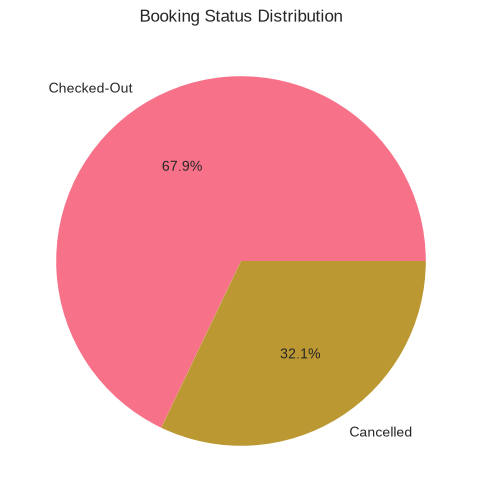

In [66]:
plt.figure(figsize=(8, 6))
status_counts = df['booking_status'].value_counts()
plt.pie(status_counts.values, labels=['Checked-Out', 'Cancelled'], autopct='%1.1f%%')
plt.title('Booking Status Distribution')
plt.show()

# ADR Distribution by Hotel Type

<Figure size 1000x600 with 0 Axes>

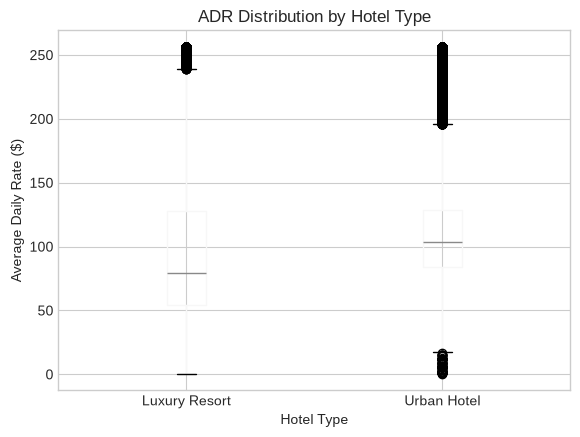

In [69]:
if 'hotel_type' in df.columns:
    plt.figure(figsize=(10, 6))
    df.boxplot(column='avg_daily_rate', by='hotel_type')
    plt.title('ADR Distribution by Hotel Type')
    plt.suptitle('')
    plt.xlabel('Hotel Type')
    plt.ylabel('Average Daily Rate ($)')
    plt.show()

# Correlation Heatmap

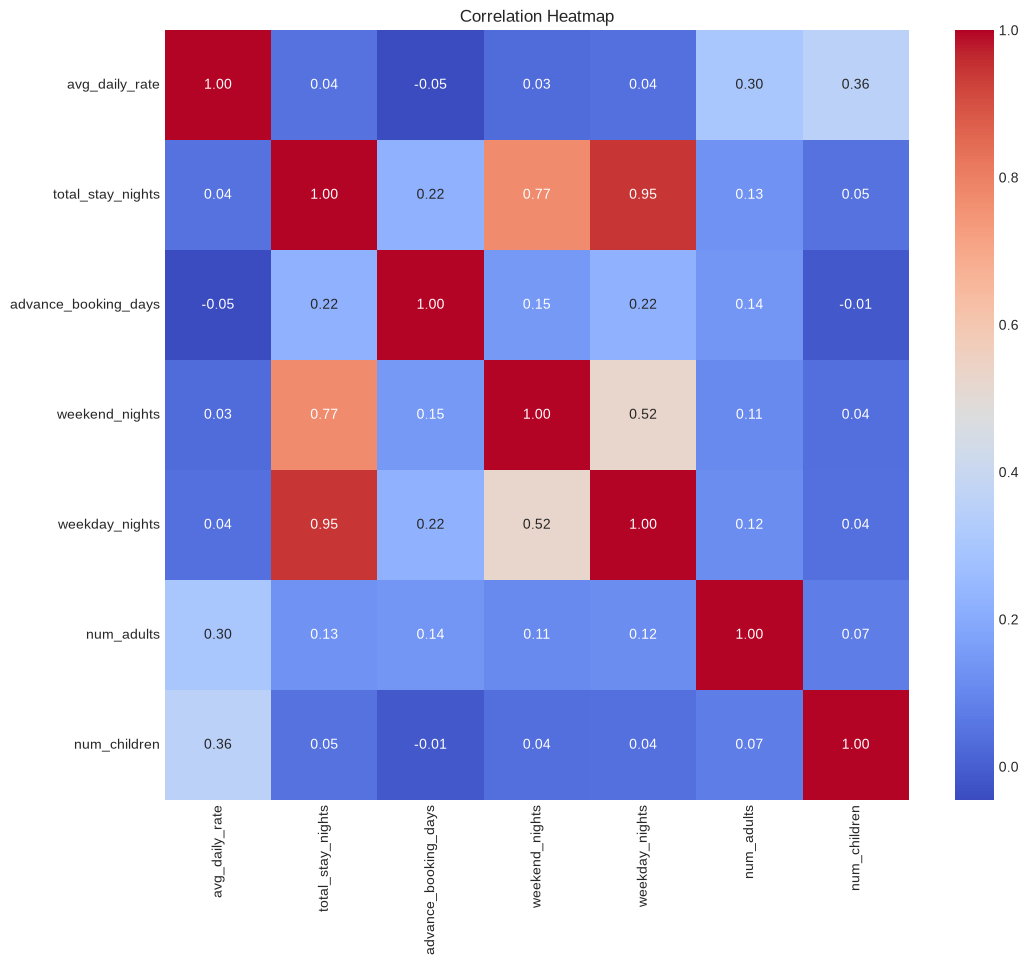

In [70]:
plt.figure(figsize=(12, 10))
numeric_cols = ['avg_daily_rate', 'total_stay_nights', 'advance_booking_days', 
                'weekend_nights', 'weekday_nights', 'num_adults', 'num_children']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()